# χ行列の主要エラー要素とdrive校正

このノートは**設定と実行だけ**を担当します。関数、QPT、CPTP射影、fit、描画、キャッシュ処理はPython側へ移しました。

- 設定API: `chi_error_nbar_workflow.py`
- 解析実装: `chi_error_nbar_analysis_impl.py`
- 独立検証ステージ: `chi_error_nbar_stages.py`
- drive補正式: `drive_amplitude_calibration.py`
- drive再QPT解析: `drive_calibration_qpt_analysis.py`

通常は下の設定セルだけ変更し、最後の`workflow.run(CONFIG)`を実行してください。重いフラグは既定で`False`です。

In [2]:
import importlib

import numpy as np
import pandas as pd
from IPython.display import display

import chi_error_nbar_workflow as workflow
import chi_error_nbar_stages as stages
workflow = importlib.reload(workflow)
stages = importlib.reload(stages)

## 1. 共通設定

通常変更するのはこのセルです。

In [3]:
CONFIG = workflow.default_config()

CONFIG["OUTPUT_DIR"] = "results/chi_error_element_fit"
CONFIG["NBAR_GRID"] = np.r_[0.01, np.arange(0.25, 20.0001, 0.25)]
CONFIG["FIT_DEGREE"] = 4
CONFIG["ERROR_CHANNEL_CONVENTION"] = "undo_before_actual"

# 並列数。高n_barではメモリ使用量も増えるため、まず4を推奨。
CONFIG["PARALLEL_WORKERS"] = 24
CONFIG["FAST_PROCESS_WORKERS"] = 24

display(pd.Series({
    key: value for key, value in CONFIG.items()
    if key not in {"SIMULATION_PARAMS", "NBAR_GRID"}
}, name="value").to_frame())

,value
OUTPUT_DIR,results/chi_error_element_fit
RECOMPUTE,False
PARALLEL_WORKERS,24
FAST_PROCESS_WORKERS,24
FIT_DEGREE,4
ERROR_CHANNEL_CONVENTION,undo_before_actual
RUN_EXACT_FULL_CHI_SWEEP,False
RUN_NUMERICAL_CONVERGENCE,False
RUN_NOISE_SOURCE_ABLATION,False
FORCE_RECOMPUTE_PUBLICATION_CACHE,False


## 2. Hamiltonian・ノイズ設定

物理条件を変更する場合はこのセルだけ編集します。

In [4]:
SIMULATION_PARAMS = CONFIG["SIMULATION_PARAMS"]
SIMULATION_PARAMS.update({
    "A": 0.125,
    "delta": 0.5,
    "rho0": 0.0,
    "time_points": 500,
    "t_gate_phys": 100e-6,
    "heating_rate_phys": 10.0,
    "dephasing_rate_phys": 18.0,
    "T2_star": 0.3,
    "rayleigh_rate_phys": 3.0,
    "raman_rate_phys": 1.0,
    "eta": 0.1,
    "laser_intensity_fluctuation": 0.0,
    "laser_detuning_fluctuation": 0.0,
    "laser_rotation_angle_fluctuation": 0.0,
    "laser_noise_samples": 1,
    "laser_noise_seed": 1234,
    "use_full_order": True,
    "show_progress": True,
    "parallel_workers": CONFIG["PARALLEL_WORKERS"],
})
display(pd.Series(SIMULATION_PARAMS, name="value").to_frame())

,value
A,0.125
delta,0.5
rho0,0.0
time_points,500
t_gate_phys,0.0001
heating_rate_phys,10.0
dephasing_rate_phys,18.0
T2_star,0.3
rayleigh_rate_phys,3.0
raman_rate_phys,1.0


## 3. 論文用検証フラグ

`False`では保存済みキャッシュを読みます。`True`は不足点を計算します。`FORCE_*`は既存キャッシュも再計算します。

In [5]:
CONFIG.update({
    "RECOMPUTE": False,
    "RUN_EXACT_FULL_CHI_SWEEP": False,
    "RUN_NUMERICAL_CONVERGENCE": False,
    "RUN_NOISE_SOURCE_ABLATION": False,
    "FORCE_RECOMPUTE_PUBLICATION_CACHE": False,
    "CONVERGENCE_NBARS": [0.01, 4.0, 20.0],
    "ABLATION_NBARS": [0.01, 1.0, 4.0, 10.0, 20.0],
    "BOOTSTRAP_SAMPLES": 1000,
    "BOOTSTRAP_SEED": 20260805,
    "CPTP_TOLERANCE": 1e-11,
    "CPTP_MAX_ITERATIONS": 5000,
    "FORCE_RECOMPUTE_ADVANCED_QPT": False,
    "RUN_PHYSICAL_CONTROL_QPT": False,
    "RUN_PARAMETER_ROBUSTNESS_QPT": False,
    "CONTROL_VALIDATION_NBARS": [0.01, 1.0, 2.0, 3.0, 4.0],
    "ROBUSTNESS_NBARS": [0.01, 1.0, 2.0, 3.0, 4.0],
})

## 4. $h_{XX}$ drive-amplitude校正

`RUN_HXX_DRIVE_CALIBRATION_QPT=True`にすると、補正振幅でfull-order master-equation QPTを実行します。各温度点は独立キャッシュなので中断・再開できます。

In [6]:
CONFIG.update({
    "RUN_HXX_DRIVE_CALIBRATION_QPT": False,
    "FORCE_RECOMPUTE_HXX_DRIVE_QPT": False,
    "HXX_DRIVE_CALIBRATION_NBARS": [
        0.01, 1.0, 2.0, 4.0, 6.0, 8.0, 10.0, 12.0, 16.0, 20.0,
    ],
    "HXX_MAX_FEEDBACK_ITERATIONS": 2,
    "HXX_CONVERGENCE_TOL_RAD": 2e-3,
    "HXX_MAX_AMPLITUDE_FACTOR": 1.6,
    "TARGET_XX_ANGLE_RAD": np.pi / 4.0,

    # 実機値がある場合: K = f_mode[Hz] * t_gate[s]
    "KIRCHHOFF_REFERENCE_K": None,
    "KIRCHHOFF_LOOP_NUMBER": 1.0,
    "KIRCHHOFF_SCAN_K_MAX": 250.0,
})

## 5. 基本解析と保存済み検証の読込

設定を検証した後、解析本体を一度だけ呼びます。重いフラグが`False`なら既存キャッシュを読みます。以下の独立検証セルより先に一度実行してください。

Sweep points: 81 (0.01 ... 20.0)
Cache: results/chi_error_element_fit/chi_error_element_sweep.csv
RECOMPUTE = False
data_source
direct_simulation    81


,n_bar,chi_XX_XX,chi_II_XX_real,chi_II_XX_imag,chi_II_XX_abs,data_source
0,0.01,0.000353,-0.000524,0.013702,0.013712,direct_simulation
1,0.25,0.000537,-0.000652,0.017362,0.017375,direct_simulation
2,0.50,0.000784,-0.000783,0.021154,0.021168,direct_simulation
3,0.75,0.001086,-0.000912,0.024922,0.024938,direct_simulation
4,1.00,0.001443,-0.001040,0.028665,0.028684,direct_simulation


,n_bar,chi_XX_XX,chi_II_XX_real,chi_II_XX_imag,chi_II_XX_abs,data_source
76,19.00,0.101549,-0.006603,0.218649,0.218748,direct_simulation
77,19.25,0.103312,-0.006645,0.220304,0.220404,direct_simulation
78,19.50,0.105075,-0.006686,0.221939,0.222039,direct_simulation
79,19.75,0.106836,-0.006727,0.223554,0.223655,direct_simulation
80,20.00,0.108596,-0.006767,0.225149,0.225251,direct_simulation


,element,degree,R_squared,RMSE,max_abs_residual
0,"\chi_{XX,XX}",1,0.946932,0.007761,0.012785
1,"\chi_{XX,XX}",2,0.997520,0.001678,0.003694
2,"\chi_{XX,XX}",3,0.999973,0.000174,0.000442
3,"\chi_{XX,XX}",4,1.000000,0.000007,0.000022
4,"\chi_{XX,XX}",5,1.000000,0.000003,0.000009
5,"|\chi_{II,XX}|",1,0.968919,0.010920,0.022739
6,"|\chi_{II,XX}|",2,0.999973,0.000322,0.000999
7,"|\chi_{II,XX}|",3,0.999995,0.000139,0.000280
8,"|\chi_{II,XX}|",4,1.000000,0.000033,0.000080
9,"|\chi_{II,XX}|",5,1.000000,0.000004,0.000011


,element,degree,n_bar_anchor,value_at_anchor,R_squared,RMSE,max_abs_residual,equation,a1,a2,a3,a4
0,"\chi_{XX,XX}",4,0.01,0.000353,1.0,0.000007,0.000022,y(n) = 3.52629218e-04 + 6.58124182e-04(n-0.01)...,0.000658,0.000465,-0.000015,1.788963e-07
1,"|\chi_{II,XX}|",4,0.01,0.013712,1.0,0.000033,0.000080,y(n) = 1.37116490e-02 + 1.54009743e-02(n-0.01)...,0.015401,-0.000220,-0.000004,1.387494e-07


**\chi_{XX,XX}**: `y(n) = 3.52629218e-04 + 6.58124182e-04(n-0.01)^1 + 4.64640231e-04(n-0.01)^2 - 1.49132984e-05(n-0.01)^3 + 1.78896312e-07(n-0.01)^4`<br>$R^2=0.99999996$, RMSE = 6.598e-06

**|\chi_{II,XX}|**: `y(n) = 1.37116490e-02 + 1.54009743e-02(n-0.01)^1 - 2.20121505e-04(n-0.01)^2 - 3.81084908e-06(n-0.01)^3 + 1.38749425e-07(n-0.01)^4`<br>$R^2=0.99999972$, RMSE = 3.305e-05

Saved: results/chi_error_element_fit/chi_error_element_fit_summary.csv


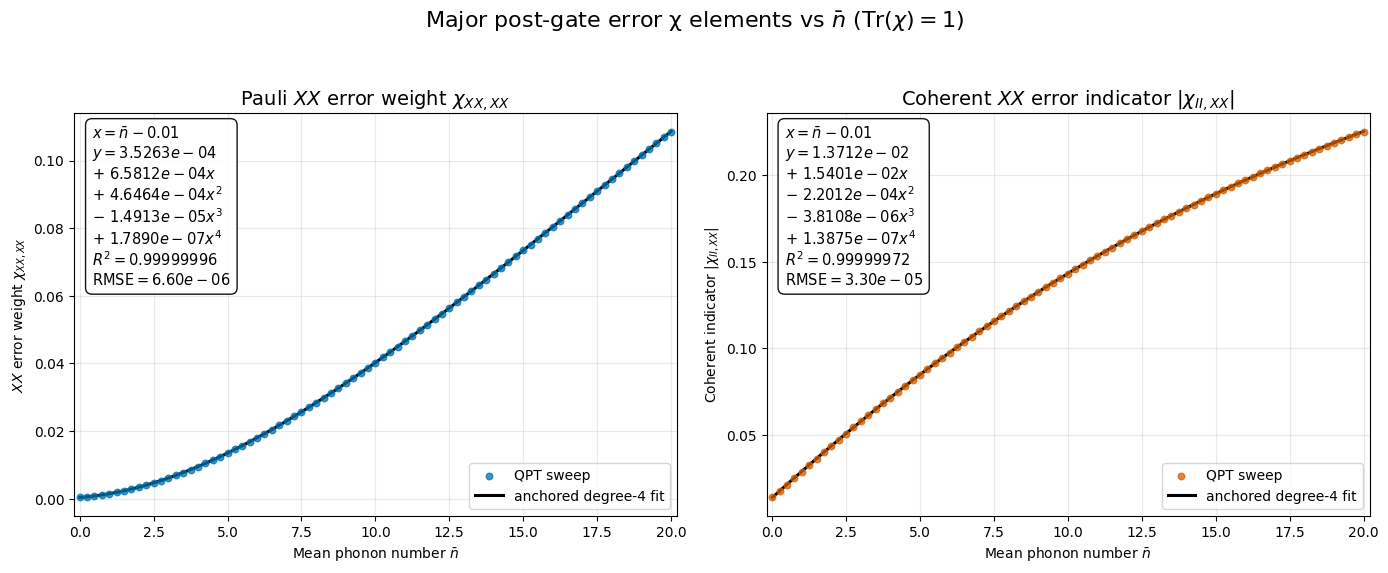

Saved: results/chi_error_element_fit/chi_error_elements_vs_nbar_fit.png
Saved: results/chi_error_element_fit/chi_error_elements_vs_nbar_fit.pdf
Saved: results/chi_error_element_fit/chi_error_element_fit_curves.csv


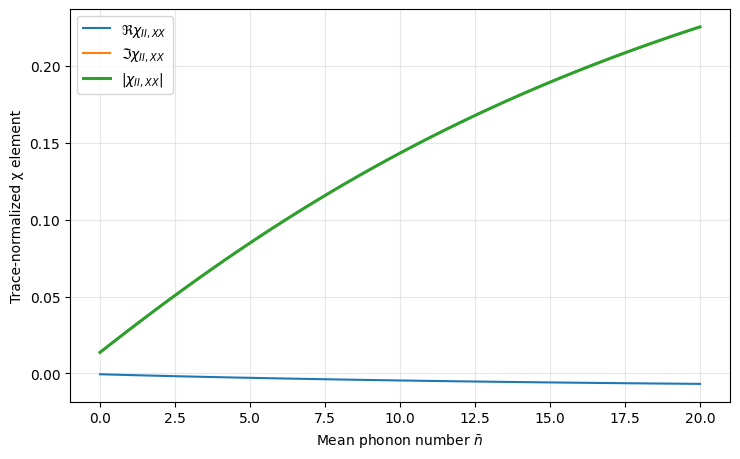

Saved: results/chi_error_element_fit/chi_II_XX_complex_components.png
Selected other major Pauli noises: ['IX', 'XI']
Selection threshold: 1.0% of max chi[XX,XX]


,pauli,max_over_sweep,value_at_nbar_0p01,value_at_nbar_20,relative_to_XX_peak
2,IX,6.792169e-03,5.489609e-04,6.792169e-03,0.062546
3,XI,6.792169e-03,5.489658e-04,6.792169e-03,0.062546
4,IZ,1.742226e-04,1.742226e-04,1.307732e-04,0.001604
5,ZI,1.742221e-04,1.742221e-04,1.307772e-04,0.001604
6,YX,1.742133e-04,1.742133e-04,1.306923e-04,0.001604
7,XY,1.742125e-04,1.742125e-04,1.306950e-04,0.001604
8,IY,1.149983e-04,7.137986e-05,1.149909e-04,0.001059
9,YI,1.149873e-04,7.138454e-05,1.149873e-04,0.001059
10,ZX,1.147266e-04,7.136353e-05,1.147266e-04,0.001056
11,XZ,1.147244e-04,7.136854e-05,1.147244e-04,0.001056


Saved: results/chi_error_element_fit/chi_pauli_diagonal_noise_ranking.csv


,element,pauli,degree,n_bar_anchor,value_at_anchor,R_squared,RMSE,max_abs_residual,equation,a1,a2,a3,a4
0,"chi_{IX,IX}",IX,4,0.01,0.000549,1.0,8.403856e-07,0.000004,y(n) = 5.48960862e-04 + 5.35969980e-04(n-0.01)...,0.000536,-0.000016,3.219822e-07,-3.759491e-09
1,"chi_{XI,XI}",XI,4,0.01,0.000549,1.0,8.423585e-07,0.000004,y(n) = 5.48965783e-04 + 5.35964832e-04(n-0.01)...,0.000536,-0.000016,3.219415e-07,-3.758916e-09


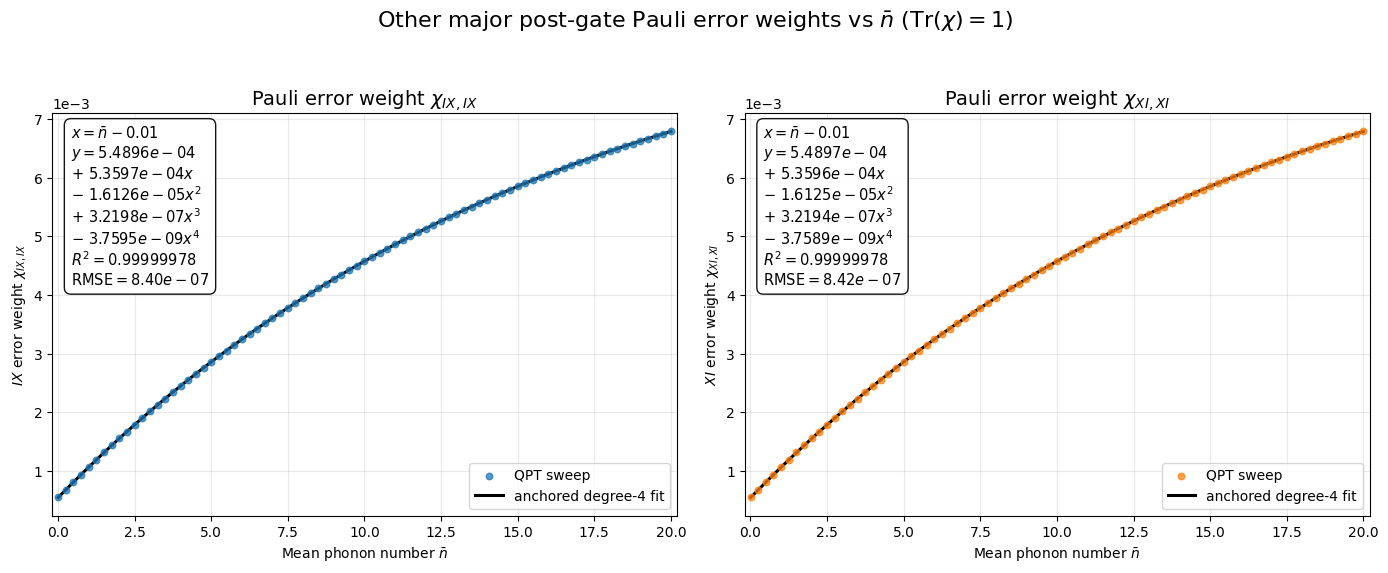

Saved: results/chi_error_element_fit/chi_other_major_noise_fit_summary.csv
Saved: results/chi_error_element_fit/chi_other_major_noise_vs_nbar_fit.png
Saved: results/chi_error_element_fit/chi_other_major_noise_vs_nbar_fit.pdf
Saved: results/chi_error_element_fit/chi_other_major_noise_fit_curves.csv
Heavy publication checks:
 exact full chi sweep = False
 numerical convergence = False
 noise-source ablation = False
Exact full-chi cache: 81/81 points


,n_bar,phonon_dim,raw_trace_real,raw_trace_imag,trace_normalized_hermiticity_fro,convention_error_fro,dimension,choi_trace,expected_choi_trace_for_tp,choi_trace_error,tp_frobenius_error,tp_max_abs_error,min_choi_eigenvalue,negative_choi_eigenvalue_count,tp_pass,cp_pass
0,0.01,20,16.0,1.799442e-17,8.226611e-16,0.0,4,4.0,4,4.441120e-16,1.681932e-15,7.229287e-16,1.471214e-07,0,True,True
1,0.25,21,16.0,1.985790e-18,6.069958e-16,0.0,4,4.0,4,4.964476e-19,2.740699e-15,1.332274e-15,1.494379e-07,0,True,True
2,0.50,22,16.0,-2.433716e-17,5.477606e-16,0.0,4,4.0,4,6.084290e-18,1.991040e-15,9.281566e-16,1.420811e-07,0,True,True
3,0.75,23,16.0,6.855207e-18,4.378303e-16,0.0,4,4.0,4,1.713802e-18,2.008340e-15,7.771618e-16,1.823241e-07,0,True,True
4,1.00,25,16.0,2.000288e-17,5.075605e-16,0.0,4,4.0,4,4.441174e-16,2.288675e-15,8.881810e-16,1.429901e-07,0,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
76,19.00,335,16.0,-3.857103e-18,2.477808e-16,0.0,4,4.0,4,2.664535e-15,9.018078e-15,4.440892e-15,-6.700579e-07,1,True,False
77,19.25,340,16.0,3.542461e-18,2.772767e-16,0.0,4,4.0,4,3.552714e-15,1.267060e-14,6.217249e-15,-6.877848e-07,1,True,False
78,19.50,345,16.0,-6.149587e-18,2.767528e-16,0.0,4,4.0,4,1.537406e-18,4.698263e-15,2.069290e-15,1.507784e-07,0,True,True
79,19.75,350,16.0,2.211852e-18,2.568161e-16,0.0,4,4.0,4,2.664535e-15,1.012739e-14,4.006352e-15,-1.492663e-06,1,True,False


,n_bar,case,phonon_dim,time_points,solver_atol,solver_rtol,chi_frobenius_difference_from_baseline,delta_chi_XX_XX,delta_abs_chi_II_XX,delta_chi_IX_IX,delta_chi_XI_XI
0,0.01,baseline,20,500,1.000000e-12,1.000000e-09,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
1,0.01,phonon_cutoff_1p2x,24,500,1.000000e-12,1.000000e-09,1.410168e-07,9.710042e-09,1.165605e-08,7.880690e-09,-8.881181e-09
2,0.01,time_grid_750,20,750,1.000000e-12,1.000000e-09,1.582912e-05,-3.052450e-07,-1.117783e-05,1.166916e-08,5.758157e-09
3,0.01,strict_solver_tol,20,500,1.000000e-13,1.000000e-10,8.278577e-08,1.174198e-10,-1.357508e-08,3.024249e-09,-1.277186e-09
4,4.00,baseline,67,500,1.000000e-12,1.000000e-09,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
5,4.00,phonon_cutoff_1p2x,81,500,1.000000e-12,1.000000e-09,1.402904e-06,3.215637e-08,7.809372e-07,-2.203228e-07,-1.887032e-07
6,4.00,time_grid_750,67,750,1.000000e-12,1.000000e-09,1.466400e-05,-1.312070e-06,-1.027634e-05,-1.418031e-08,-2.657212e-08
7,4.00,strict_solver_tol,67,500,1.000000e-13,1.000000e-10,1.712174e-07,5.031036e-09,-6.898890e-08,1.693588e-08,4.986855e-09
8,20.00,baseline,354,500,1.000000e-12,1.000000e-09,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
9,20.00,phonon_cutoff_1p2x,425,500,1.000000e-12,1.000000e-09,5.976264e-07,-2.074160e-08,7.789447e-08,7.641196e-09,4.023760e-08


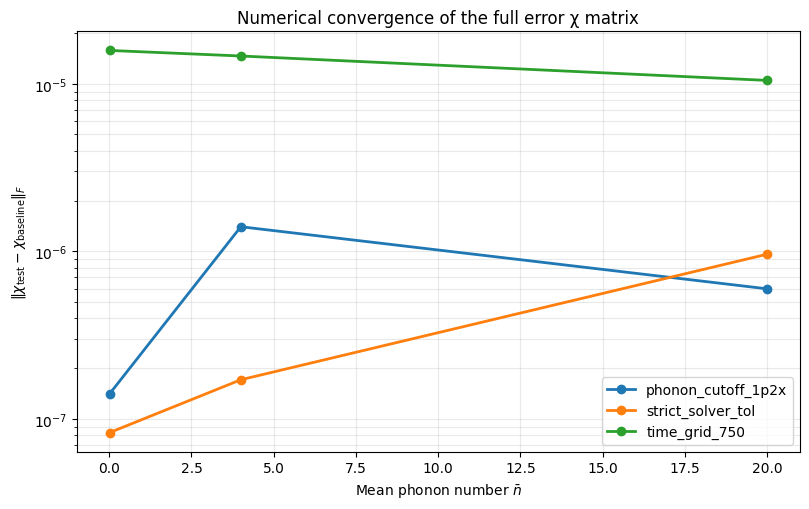

Saved: results/chi_error_element_fit/numerical_convergence/numerical_convergence_summary.csv


,n_bar,noise_source,observable,leave_one_out_all_minus_without,isolated_only_minus_none
0,0.01,motional_heating,chi_XX_XX,7.957329e-07,5.386332e-07
1,0.01,motional_heating,abs_chi_II_XX,8.271729e-06,4.243323e-06
2,0.01,motional_heating,chi_IX_IX,2.428858e-04,2.434732e-04
3,0.01,motional_heating,chi_XI_XI,2.428943e-04,2.434591e-04
4,0.01,motional_dephasing,chi_XX_XX,1.611454e-04,1.610577e-04
...,...,...,...,...,...
75,20.00,spin_dephasing,chi_XI_XI,-2.253780e-06,-3.397647e-07
76,20.00,photon_scattering,chi_XX_XX,-7.566620e-05,-7.754002e-05
77,20.00,photon_scattering,abs_chi_II_XX,-1.576945e-04,-1.603354e-04
78,20.00,photon_scattering,chi_IX_IX,1.992962e-05,2.428152e-05


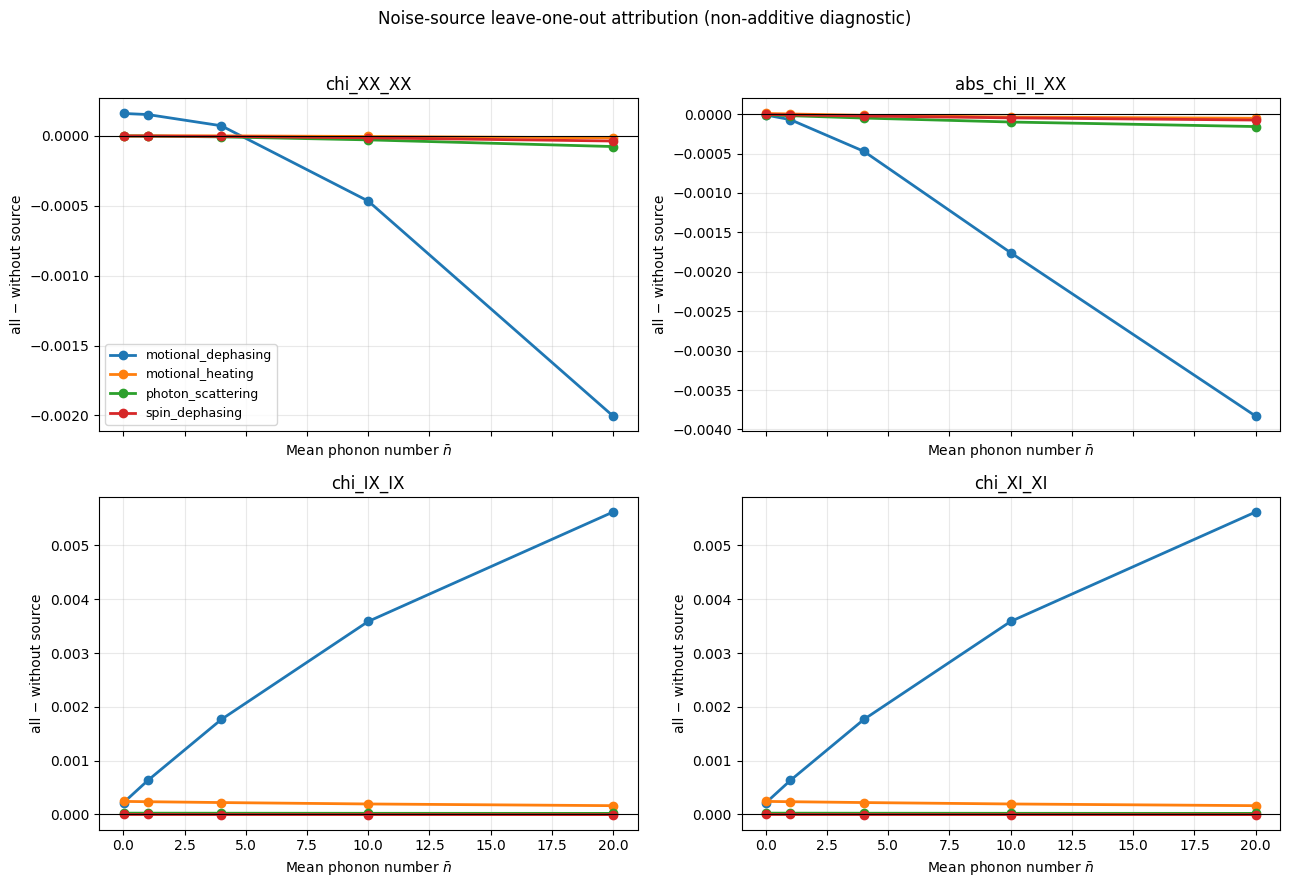

Saved: results/chi_error_element_fit/noise_source_ablation/noise_ablation_attribution.csv


,rank,component,row_pauli,column_pauli,is_diagonal,max_abs_over_sweep,mean_abs_over_sweep
0,1,"II,II",II,II,True,9.975668e-01,9.456226e-01
1,2,"II,XX",II,XX,False,2.252506e-01,1.348869e-01
2,3,"XX,XX",XX,XX,True,1.085955e-01,4.485163e-02
3,4,"IX,IX",IX,IX,True,6.792170e-03,4.271583e-03
4,5,"XI,XI",XI,XI,True,6.792169e-03,4.271585e-03
5,6,"IX,XI",IX,XI,False,6.767138e-03,4.246555e-03
6,7,"IZ,IZ",IZ,IZ,True,1.742226e-04,1.359991e-04
7,8,"ZI,ZI",ZI,ZI,True,1.742221e-04,1.360003e-04
8,9,"YX,YX",YX,YX,True,1.742133e-04,1.359290e-04
9,10,"XY,XY",XY,XY,True,1.742125e-04,1.359305e-04


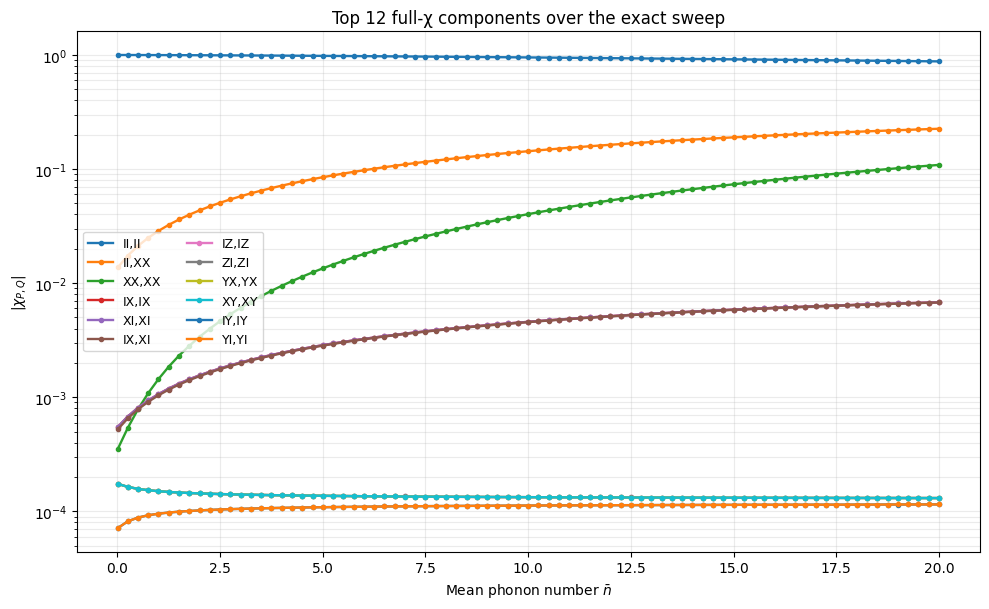

Saved: results/chi_error_element_fit/exact_full_chi/full_chi_component_ranking.csv


,target,degree,R_squared,RMSE,max_abs_residual,AICc,BIC,CV_RMSE_5fold,equation,best_AICc,best_CV
0,chi_XX_XX,1,0.946932,7.760765e-03,0.012785,-785.054610,-782.710794,0.010479,y(n) = 3.52629218e-04 + 4.77527537e-03(n-0.01)^1,False,False
1,chi_XX_XX,2,0.997520,1.677558e-03,0.003694,-1031.093536,-1026.458484,0.003749,y(n) = 3.52629218e-04 + 2.23953120e-03(n-0.01)...,False,False
2,chi_XX_XX,3,0.999973,1.736828e-04,0.000442,-1396.329630,-1389.457971,0.000668,y(n) = 3.52629218e-04 + 9.17962849e-04(n-0.01)...,False,False
3,chi_XX_XX,4,1.000000,6.597804e-06,0.000022,-1923.935023,-1914.883542,0.000036,y(n) = 3.52629218e-04 + 6.58124182e-04(n-0.01)...,False,True
4,chi_XX_XX,5,1.000000,3.109257e-06,0.000009,-2043.542556,-2032.370311,0.000048,y(n) = 3.52629218e-04 + 6.43673131e-04(n-0.01)...,True,False
5,abs_chi_II_XX,1,0.968919,1.091994e-02,0.022739,-729.730078,-727.386262,0.015573,y(n) = 1.37116490e-02 + 1.17197654e-02(n-0.01)^1,False,False
6,abs_chi_II_XX,2,0.999973,3.217210e-04,0.000999,-1298.621954,-1293.986902,0.000738,y(n) = 1.37116490e-02 + 1.53725441e-02(n-0.01)...,False,False
7,abs_chi_II_XX,3,0.999995,1.386060e-04,0.000280,-1432.876079,-1426.004420,0.000525,y(n) = 1.37116490e-02 + 1.56025015e-02(n-0.01)...,False,False
8,abs_chi_II_XX,4,1.000000,3.304733e-05,0.000080,-1662.919978,-1653.868497,0.000242,y(n) = 1.37116490e-02 + 1.54009743e-02(n-0.01)...,False,False
9,abs_chi_II_XX,5,1.000000,4.116071e-06,0.000011,-1998.099043,-1986.926797,0.000058,y(n) = 1.37116490e-02 + 1.53195461e-02(n-0.01)...,True,True


,target,chosen_degree,equation,R_squared,RMSE,AICc,BIC,CV_RMSE_5fold,bootstrap_samples,bootstrap_seed
0,chi_XX_XX,4,y(n) = 3.52629218e-04 + 6.58124182e-04(n-0.01)...,1.0,6.597804e-06,-1923.935023,-1914.883542,0.000036,1000,20260805
1,abs_chi_II_XX,4,y(n) = 1.37116490e-02 + 1.54009743e-02(n-0.01)...,1.0,3.304733e-05,-1662.919978,-1653.868497,0.000242,1000,20260805
2,chi_IX_IX,4,y(n) = 5.48960862e-04 + 5.35969980e-04(n-0.01)...,1.0,8.403856e-07,-2257.757298,-2248.705818,0.000005,1000,20260805
3,chi_XI_XI,4,y(n) = 5.48965783e-04 + 5.35964832e-04(n-0.01)...,1.0,8.423585e-07,-2257.377431,-2248.325951,0.000005,1000,20260805


,target,coefficient,estimate,ci95_lower,ci95_upper
0,chi_XX_XX,a0_anchor,3.526292e-04,3.526292e-04,3.526292e-04
1,chi_XX_XX,a1,6.581242e-04,6.554713e-04,6.607083e-04
2,chi_XX_XX,a2,4.646402e-04,4.639461e-04,4.653548e-04
3,chi_XX_XX,a3,-1.491330e-05,-1.497149e-05,-1.485770e-05
4,chi_XX_XX,a4,1.788963e-07,1.774487e-07,1.803992e-07
5,abs_chi_II_XX,a0_anchor,1.371165e-02,1.371165e-02,1.371165e-02
6,abs_chi_II_XX,a1,1.540097e-02,1.538819e-02,1.541325e-02
7,abs_chi_II_XX,a2,-2.201215e-04,-2.233023e-04,-2.166838e-04
8,abs_chi_II_XX,a3,-3.810849e-06,-4.101414e-06,-3.541870e-06
9,abs_chi_II_XX,a4,1.387494e-07,1.317239e-07,1.464881e-07


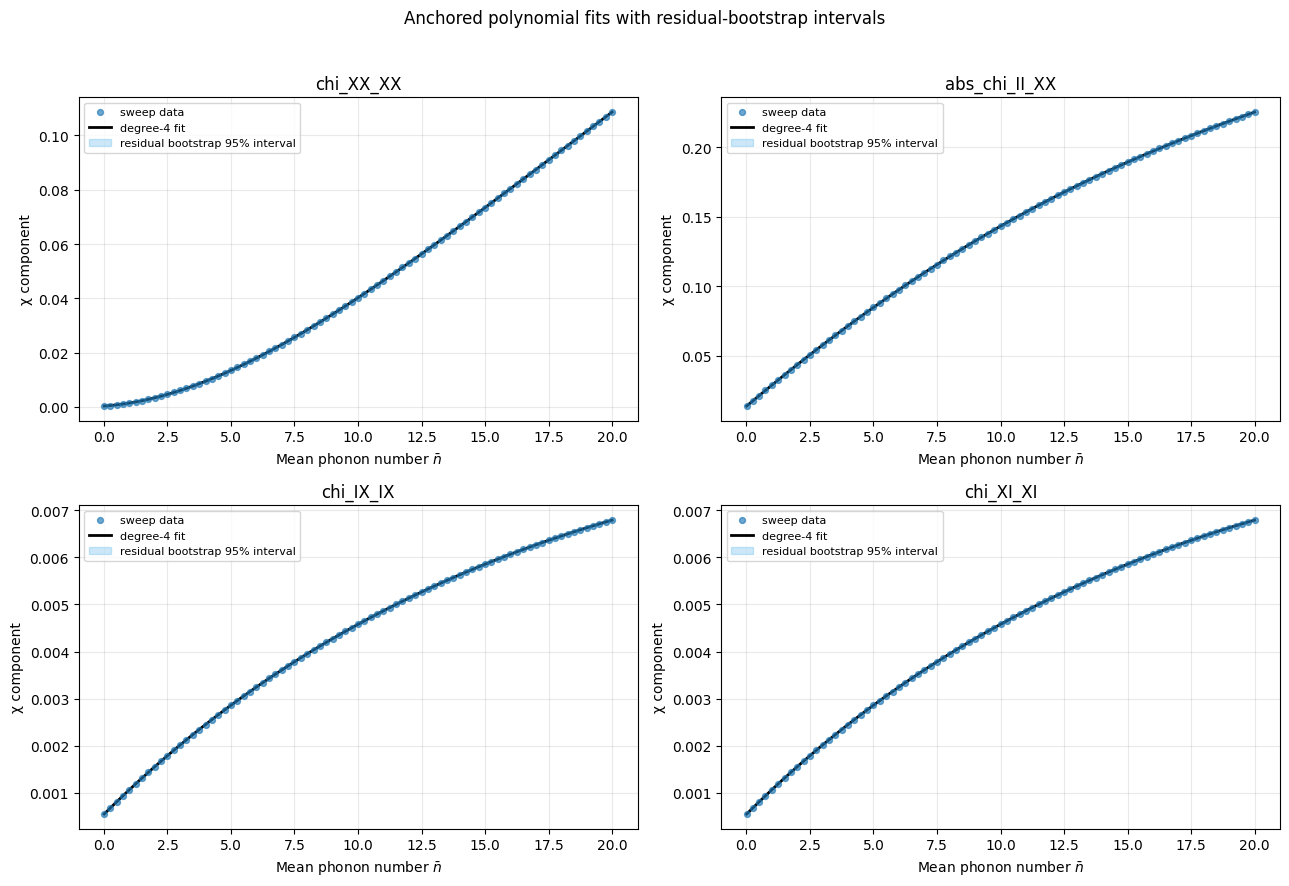

Saved: results/chi_error_element_fit/fit_model_comparison_aicc_bic_cv.csv
Saved: results/chi_error_element_fit/fit_selected_models_publication.csv


,count
target_element_points,81
pauli_diagonal_points,81
exact_full_chi_points,81
expected_sweep_points,81
numerical_convergence_rows,12
noise_ablation_attribution_rows,80


Saved: results/chi_error_element_fit/publication_reproducibility_manifest.json
Machine: 24 physical cores, 503.1 GiB RAM
QPT process workers: 24
RUN_PHYSICAL_CONTROL_QPT = False
RUN_PARAMETER_ROBUSTNESS_QPT = False
CPTP pass after projection: 81/81
TP pass after projection: 81/81
Top-12 ranking overlap: 12/12
Maximum full-chi projection shift: 4.0226396844631293e-07


,count,mean,std,min,25%,50%,75%,max
n_bar,81.0,1.000012e+01,5.881433e+00,1.000000e-02,5.000000e+00,1.000000e+01,1.500000e+01,2.000000e+01
raw_min_choi_eigenvalue,81.0,-1.260229e-07,3.381978e-07,-1.530079e-06,-1.880949e-07,-4.166411e-08,9.763175e-08,1.917705e-07
projected_min_choi_eigenvalue,81.0,4.142950e-08,6.190981e-08,-4.454721e-12,-1.842918e-12,-6.624579e-13,9.763175e-08,1.917705e-07
projected_tp_frobenius_error,81.0,3.099976e-16,1.021672e-16,1.418507e-17,2.502905e-16,3.167576e-16,3.576942e-16,5.565549e-16
projection_iterations,81.0,3.419753e+00,2.084851e+00,1.000000e+00,1.000000e+00,4.000000e+00,5.000000e+00,6.000000e+00
chi_frobenius_shift,81.0,4.413400e-08,8.189755e-08,4.706180e-16,1.054097e-15,1.089891e-08,4.967739e-08,4.022640e-07
delta_chi_XX_XX,81.0,-2.909568e-09,5.401671e-09,-2.646026e-08,-3.281550e-09,-7.129234e-10,-2.775558e-17,1.249001e-16
delta_abs_chi_II_XX,81.0,1.467411e-11,7.651459e-11,-1.387779e-16,1.908196e-17,1.379882e-12,7.405687e-12,6.822179e-10
delta_chi_IX_IX,81.0,-2.909560e-09,5.401662e-09,-2.646026e-08,-3.281526e-09,-7.129233e-10,-1.734723e-17,9.280771e-17
delta_chi_XI_XI,81.0,-2.909560e-09,5.401662e-09,-2.646026e-08,-3.281526e-09,-7.129233e-10,-3.035766e-17,5.637851e-17


,rank,component,max_abs_over_sweep
0,1,"II,II",9.975668e-01
1,2,"II,XX",2.252506e-01
2,3,"XX,XX",1.085955e-01
3,4,"IX,IX",6.792157e-03
4,5,"XI,XI",6.792157e-03
5,6,"IX,XI",6.767138e-03
6,7,"IZ,IZ",1.742226e-04
7,8,"ZI,ZI",1.742221e-04
8,9,"YX,YX",1.742133e-04
9,10,"XY,XY",1.742125e-04


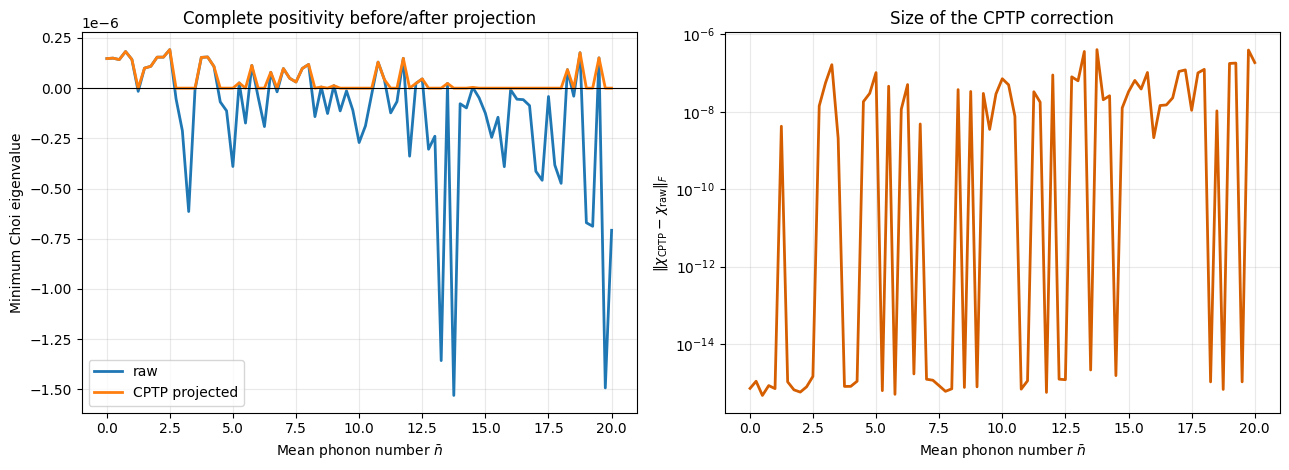

,n_bar,h_XX_rad_per_gate,gamma_XX_per_gate,chi_coherent_XX_angle_rad,generator_frobenius_norm,hamiltonian_fit_frobenius_norm,pauli_dissipator_fit_frobenius_norm,unmodeled_generator_frobenius_norm,generator_reconstruction_error,logm_imaginary_frobenius_norm,nnls_residual
0,0.01,0.013736,0.000164,0.013736,0.078418,0.077705,0.009659,0.004244,5.139690e-15,2.340176e-15,0.004244
1,0.25,0.017415,0.000234,0.017415,0.099280,0.098513,0.011131,0.005265,4.994225e-15,2.113437e-15,0.005265
2,0.50,0.021230,0.000334,0.021230,0.120935,0.120093,0.012774,0.006317,4.437264e-15,2.393154e-15,0.006317
3,0.75,0.025027,0.000461,0.025027,0.142507,0.141573,0.014527,0.007357,5.712661e-15,3.620669e-15,0.007357
4,1.00,0.028806,0.000616,0.028806,0.163989,0.162953,0.016388,0.008385,6.435113e-15,2.141107e-15,0.008385
...,...,...,...,...,...,...,...,...,...,...,...
76,19.00,0.254760,0.047296,0.254760,1.475956,1.441141,0.314016,0.054339,6.292866e-15,1.598373e-15,0.054339
77,19.25,0.257358,0.048103,0.257358,1.491344,1.455839,0.318821,0.054695,6.142634e-15,2.205442e-15,0.054695
78,19.50,0.259945,0.048908,0.259945,1.506665,1.470472,0.323610,0.055045,6.580549e-15,2.938050e-15,0.055045
79,19.75,0.262520,0.049712,0.262520,1.521920,1.485037,0.328385,0.055391,5.531660e-15,2.170050e-15,0.055391


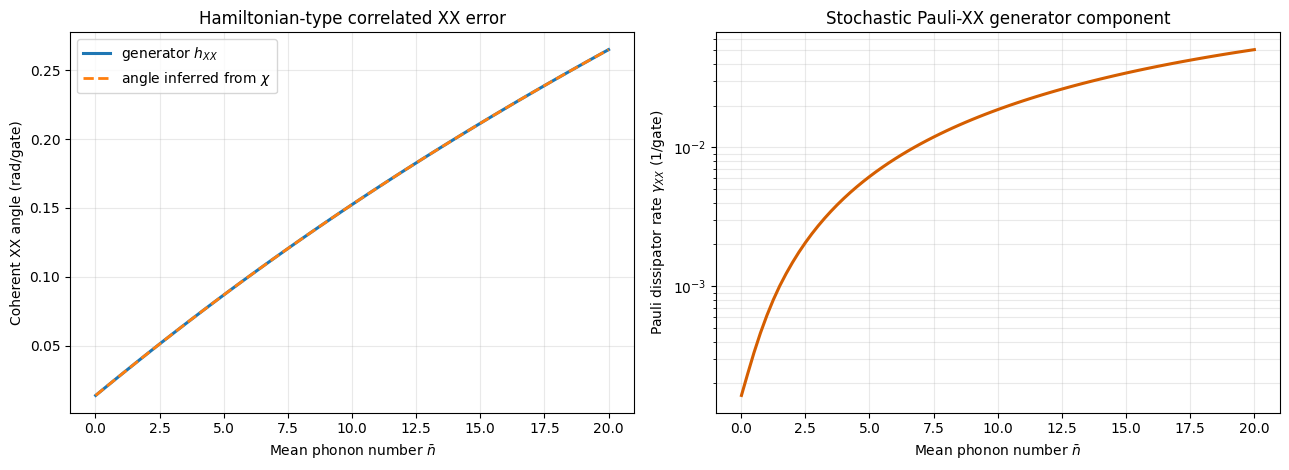

,n_bar,optimal_xx_correction_angle_rad,average_infidelity_before,average_infidelity_after,abs_chi_II_XX_before,abs_chi_II_XX_after,chi_XX_XX_before,chi_XX_XX_after,chi_IX_IX_before,chi_IX_IX_after,optimizer_success,infidelity_reduction_factor
0,0.01,0.013736,0.001947,0.001796,0.013712,0.000524,0.000353,0.000164,0.000549,0.000549,True,1.083844
1,0.25,0.017415,0.002298,0.002056,0.017375,0.000652,0.000537,0.000234,0.000677,0.000677,True,1.117640
2,0.50,0.021230,0.002706,0.002346,0.021168,0.000783,0.000784,0.000335,0.000808,0.000808,True,1.153132
3,0.75,0.025027,0.003155,0.002656,0.024938,0.000912,0.001086,0.000462,0.000937,0.000937,True,1.187928
4,1.00,0.028806,0.003644,0.002984,0.028684,0.001040,0.001443,0.000617,0.001065,0.001065,True,1.221467
...,...,...,...,...,...,...,...,...,...,...,...,...
76,19.00,0.254760,0.092629,0.047077,0.218748,0.006603,0.101549,0.044608,0.006628,0.006628,True,1.967607
77,19.25,0.257358,0.094108,0.047721,0.220404,0.006645,0.103312,0.045329,0.006670,0.006670,True,1.972024
78,19.50,0.259945,0.095584,0.048362,0.222039,0.006686,0.105075,0.046047,0.006711,0.006711,True,1.976429
79,19.75,0.262520,0.097058,0.048999,0.223655,0.006727,0.106836,0.046762,0.006752,0.006752,True,1.980811


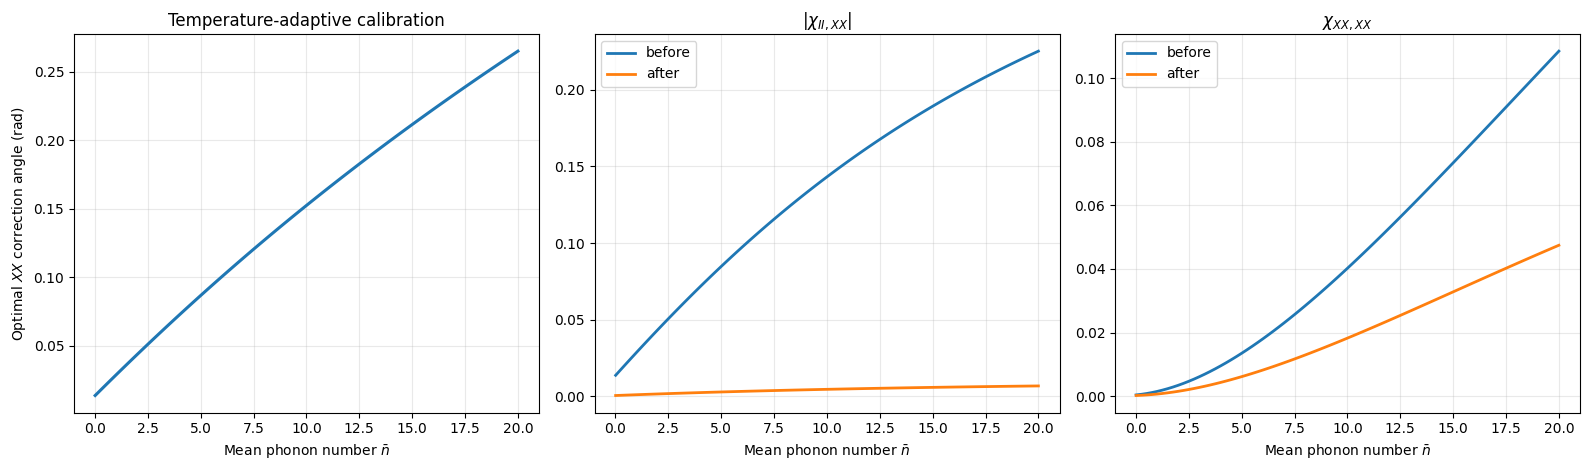

,n_bar,candidate,kind,factor,chi_II_II,chi_XX_XX,abs_chi_II_XX,coherent_XX_equivalent_weight,chi_IX_IX,chi_XI_XI,average_infidelity,control_score
0,0.01,baseline,baseline,1.00,0.997567,0.000353,0.013712,0.000188,0.000549,0.000549,0.001947,0.001639
1,1.00,baseline,baseline,1.00,0.995445,0.001443,0.028684,0.000827,0.001065,0.001065,0.003644,0.004399
2,2.00,baseline,baseline,1.00,0.992524,0.003382,0.043403,0.001898,0.001556,0.001556,0.005981,0.008391
3,3.00,baseline,baseline,1.00,0.988903,0.006083,0.057671,0.003363,0.002016,0.002016,0.008878,0.013478
4,4.00,amplitude_1.050,amplitude,1.05,0.988286,0.005157,0.002764,0.000008,0.002787,0.002787,0.009372,0.010740


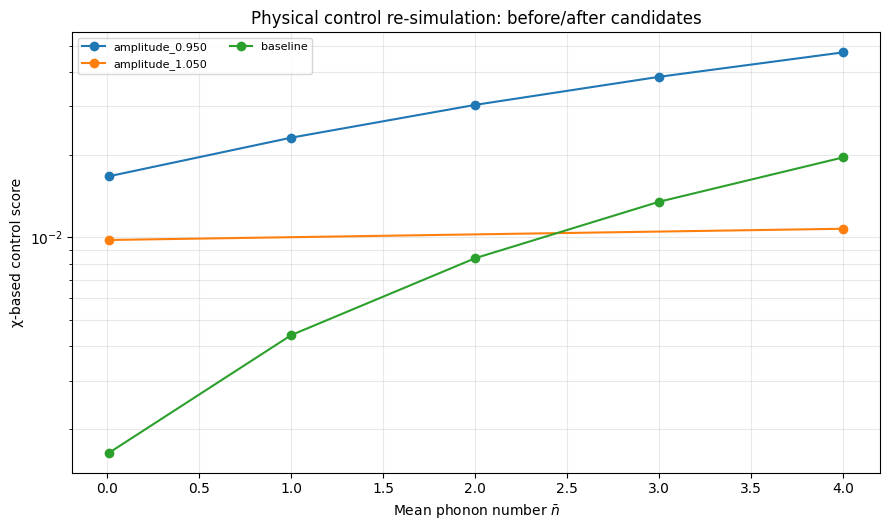

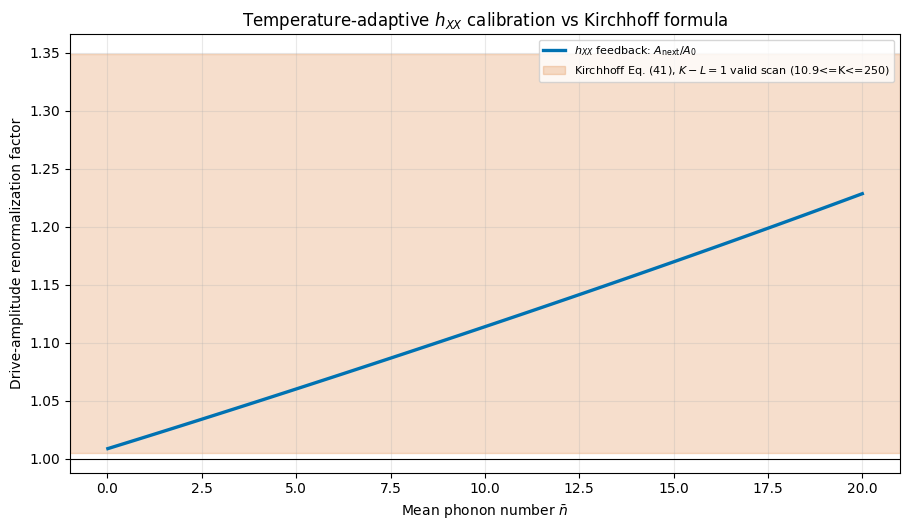

,n_bar,h_XX_baseline_rad_per_gate,inferred_actual_xx_angle_rad,A_baseline,A_hxx_first_update,A_hxx_factor
0,0.01,0.013736,0.771662,0.125,0.126108,1.008861
1,0.25,0.017415,0.767983,0.125,0.126409,1.011274
4,1.00,0.028806,0.756592,0.125,0.127357,1.018859
16,4.00,0.072711,0.712687,0.125,0.131222,1.049773
40,10.00,0.152443,0.632955,0.125,0.139241,1.113932
80,20.00,0.265083,0.520315,0.125,0.153575,1.228604


pending n_bar=4, iteration=1: A=0.13122163 (A/A0=1.0498)
pending n_bar=6, iteration=1: A=0.13385372 (A/A0=1.0708)


,n_bar,iteration,input_h_XX_rad_per_gate,A_calibrated,A_factor,cache_path,h_XX_rad_per_gate,gamma_XX_per_gate,average_infidelity,abs_chi_II_XX,chi_XX_XX,generator_imaginary_frobenius_norm,gamma_nnls_residual,cptp_projection_iterations
0,0.01,1,0.013736,0.126108,1.008861,results/chi_error_element_fit/advanced_publica...,0.000102,0.000170,0.001819,0.000545,0.000170,1.832348e-15,0.004331,1
1,1.00,1,0.028806,0.127357,1.018859,results/chi_error_element_fit/advanced_publica...,0.000212,0.000663,0.003104,0.001112,0.000664,1.896661e-15,0.008799,1
2,2.00,1,0.043740,0.128633,1.029065,results/chi_error_element_fit/advanced_publica...,0.000312,0.001662,0.004796,0.001680,0.001660,1.676744e-15,0.013324,1
3,8.00,1,0.127023,0.136527,1.092215,results/chi_error_element_fit/advanced_publica...,-0.000028,0.018494,0.023189,0.004962,0.018031,7.964521e-18,0.040551,5
4,10.00,1,0.152443,0.139241,1.113932,results/chi_error_element_fit/advanced_publica...,-0.000873,0.028315,0.032336,0.006111,0.027274,2.408069e-15,0.049721,1
5,12.00,1,0.176799,0.142000,1.136003,results/chi_error_element_fit/advanced_publica...,-0.002305,0.040292,0.042882,0.007450,0.038270,1.734275e-15,0.058967,1
6,12.00,2,-0.002305,0.141792,1.134340,results/chi_error_element_fit/advanced_publica...,0.000035,0.040069,0.042670,0.007121,0.038063,0.000000e+00,0.058721,1
7,16.00,1,0.222628,0.147669,1.181353,results/chi_error_element_fit/advanced_publica...,-0.007455,0.070989,0.067906,0.011291,0.065160,2.350841e-15,0.077789,5
8,16.00,2,-0.007455,0.146973,1.175786,results/chi_error_element_fit/advanced_publica...,0.000289,0.069737,0.066828,0.009226,0.064057,2.063323e-15,0.076730,6
9,20.00,1,0.265083,0.153575,1.228604,results/chi_error_element_fit/advanced_publica...,-0.016490,0.111459,0.097784,0.017304,0.098047,3.097617e-15,0.097285,6


,n_bar,iteration,input_h_XX_rad_per_gate,A_calibrated,A_factor,cache_path,h_XX_after_rad_per_gate,gamma_XX_after_per_gate,average_infidelity_after,abs_chi_II_XX_after,...,gamma_nnls_residual,cptp_projection_iterations,h_XX_before_rad_per_gate,gamma_XX_before_per_gate,average_infidelity_before,abs_chi_II_XX_before,chi_XX_XX_before,abs_h_XX_reduction_factor,infidelity_reduction_factor,h_XX_converged
0,0.01,1,0.013736,0.126108,1.008861,results/chi_error_element_fit/advanced_publica...,0.000102,0.000170,0.001819,0.000545,...,0.004331,1,0.013736,0.000164,0.001947,0.013712,0.000353,134.135210,1.070291,True
1,1.00,1,0.028806,0.127357,1.018859,results/chi_error_element_fit/advanced_publica...,0.000212,0.000663,0.003104,0.001112,...,0.008799,1,0.028806,0.000616,0.003644,0.028684,0.001443,135.628053,1.173990,True
2,2.00,1,0.043740,0.128633,1.029065,results/chi_error_element_fit/advanced_publica...,0.000312,0.001662,0.004796,0.001680,...,0.013324,1,0.043740,0.001485,0.005981,0.043403,0.003382,140.089317,1.246943,True
3,8.00,1,0.127023,0.136527,1.092215,results/chi_error_element_fit/advanced_publica...,-0.000028,0.018494,0.023189,0.004962,...,0.040551,5,0.127023,0.013153,0.029830,0.121363,0.028404,4490.073774,1.286353,True
4,10.00,1,0.152443,0.139241,1.113932,results/chi_error_element_fit/advanced_publica...,-0.000873,0.028315,0.032336,0.006111,...,0.049721,1,0.152443,0.018698,0.040282,0.143171,0.040214,174.697213,1.245736,True
5,12.00,2,-0.002305,0.141792,1.134340,results/chi_error_element_fit/advanced_publica...,0.000035,0.040069,0.042670,0.007121,...,0.058721,1,0.176799,0.024715,0.051422,0.162987,0.053025,5063.717759,1.205107,True
6,16.00,2,-0.007455,0.146973,1.175786,results/chi_error_element_fit/advanced_publica...,0.000289,0.069737,0.066828,0.009226,...,0.076730,6,0.222628,0.037523,0.074814,0.197203,0.080402,769.392744,1.119505,True
7,20.00,2,-0.016490,0.151988,1.215906,results/chi_error_element_fit/advanced_publica...,0.001203,0.107180,0.094435,0.011281,...,0.094346,6,0.265083,0.050513,0.098530,0.225251,0.108596,220.287300,1.043364,True


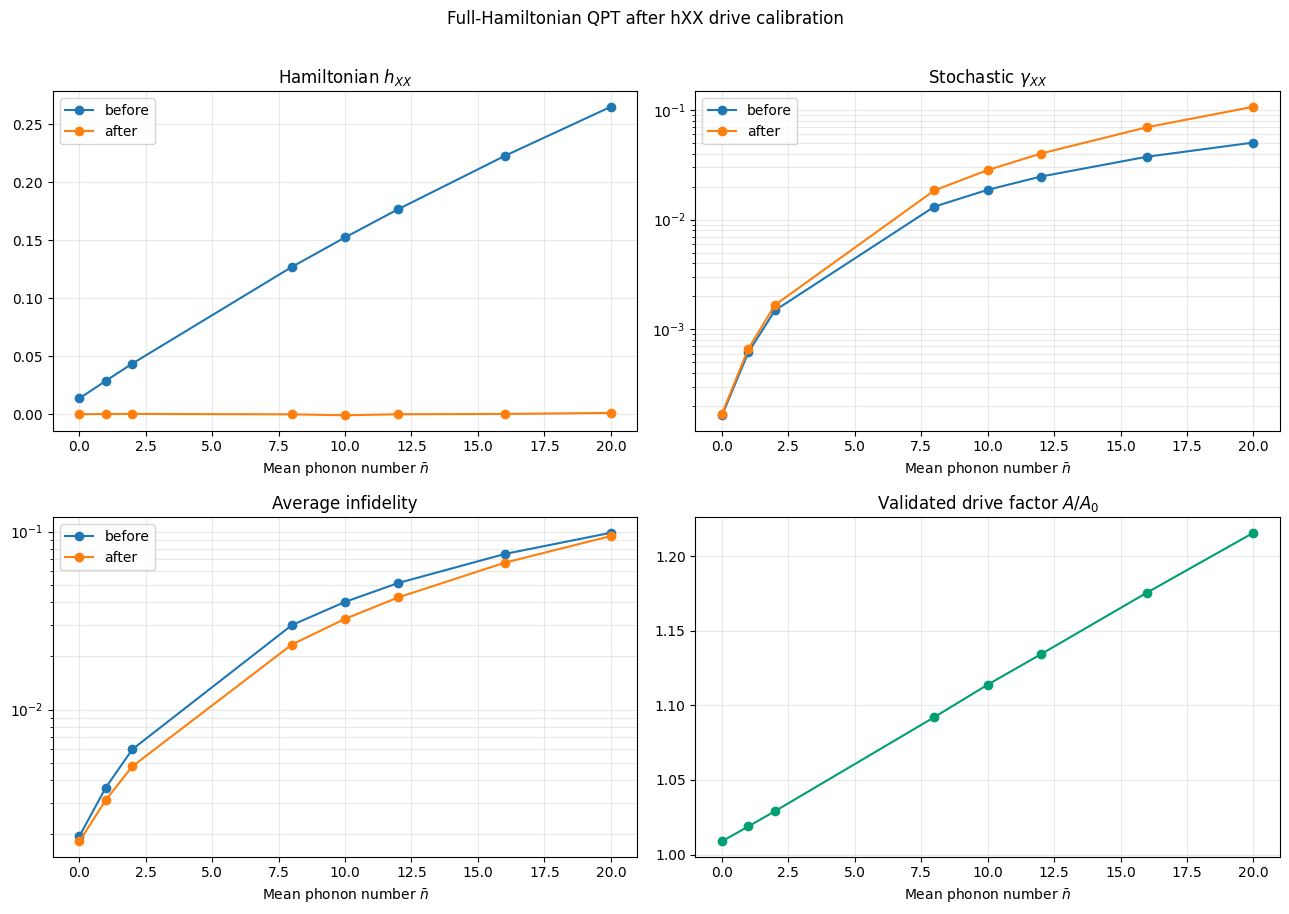

hXX physical calibration: 10/10 temperatures re-QPT, 10 converged
Parameter-robustness cache is not populated. Set RUN_PARAMETER_ROBUSTNESS_QPT=True to run 45 resumable QPT points.


,target,model,model_family,parameter_count,RMSE,AICc,BIC,CV_RMSE_5fold,equation,best_AICc_overall,best_AICc_physical
0,chi_XX_XX,thermal_linear,thermal_physics,2,4.462078e-03,-872.612940,-867.977887,0.008553,y(n) = (-1.51348521e-02)*1 + (2.85646531e-03)*...,False,False
1,chi_XX_XX,thermal_bosonic_2,thermal_physics,3,1.223872e-03,-1080.017519,-1073.145859,0.003958,y(n) = (-4.41061049e-03)*1 + (1.38147167e-03)*...,False,False
2,chi_XX_XX,thermal_bosonic_3,thermal_physics,4,1.420496e-04,-1426.685843,-1417.634362,0.000819,y(n) = (-3.74423723e-04)*1 + (3.35722386e-04)*...,False,True
3,chi_XX_XX,generic_quartic,generic_reference,5,6.414163e-06,-1926.234336,-1915.062090,0.000073,y(n) = (3.38860109e-04)*1 + (6.53129025e-04)*n...,True,False
4,abs_chi_II_XX,thermal_linear,thermal_physics,2,7.317368e-03,-792.481904,-787.846852,0.014325,y(n) = (2.43959163e-02)*1 + (5.26141133e-03)*(...,False,False
5,abs_chi_II_XX,thermal_bosonic_2,thermal_physics,3,3.000426e-04,-1307.765284,-1300.893625,0.000964,y(n) = (6.12323518e-03)*1 + (7.77460428e-03)*(...,False,False
6,abs_chi_II_XX,thermal_bosonic_3,thermal_physics,4,1.040852e-04,-1477.062412,-1468.010932,0.000558,y(n) = (5.18886154e-03)*1 + (8.01669430e-03)*(...,False,True
7,abs_chi_II_XX,generic_quartic,generic_reference,5,2.755359e-05,-1690.099181,-1678.926935,0.000288,y(n) = (1.34726124e-02)*1 + (1.54559254e-02)*n...,True,False
8,chi_IX_IX,thermal_linear,thermal_physics,2,2.777598e-04,-1322.424267,-1317.789215,0.000542,y(n) = (1.06164166e-03)*1 + (1.52852399e-04)*(...,False,False
9,chi_IX_IX,thermal_bosonic_2,thermal_physics,3,2.682970e-05,-1698.900461,-1692.028802,0.000086,y(n) = (3.70691574e-04)*1 + (2.47884478e-04)*(...,False,False


,target,model,model_family,parameter_count,RMSE,AICc,BIC,CV_RMSE_5fold,equation,best_AICc_overall,best_AICc_physical
2,chi_XX_XX,thermal_bosonic_3,thermal_physics,4,0.000142,-1426.685843,-1417.634362,0.000819,y(n) = (-3.74423723e-04)*1 + (3.35722386e-04)*...,False,True
6,abs_chi_II_XX,thermal_bosonic_3,thermal_physics,4,0.000104,-1477.062412,-1468.010932,0.000558,y(n) = (5.18886154e-03)*1 + (8.01669430e-03)*(...,False,True
10,chi_IX_IX,thermal_bosonic_3,thermal_physics,4,0.000003,-2060.070392,-2051.018911,0.000015,y(n) = (2.82111360e-04)*1 + (2.70835026e-04)*(...,False,True
14,chi_XI_XI,thermal_bosonic_3,thermal_physics,4,0.000003,-2060.093996,-2051.042516,0.000015,y(n) = (2.82120317e-04)*1 + (2.70832299e-04)*(...,False,True
18,generator_h_XX,thermal_bosonic_3,thermal_physics,4,0.000022,-1729.634338,-1720.582857,0.000103,y(n) = (5.67424617e-03)*1 + (7.82387919e-03)*(...,False,True
22,generator_gamma_XX,thermal_bosonic_3,thermal_physics,4,0.000063,-1559.248614,-1550.197133,0.000357,y(n) = (-1.40738770e-04)*1 + (1.22048651e-04)*...,False,True


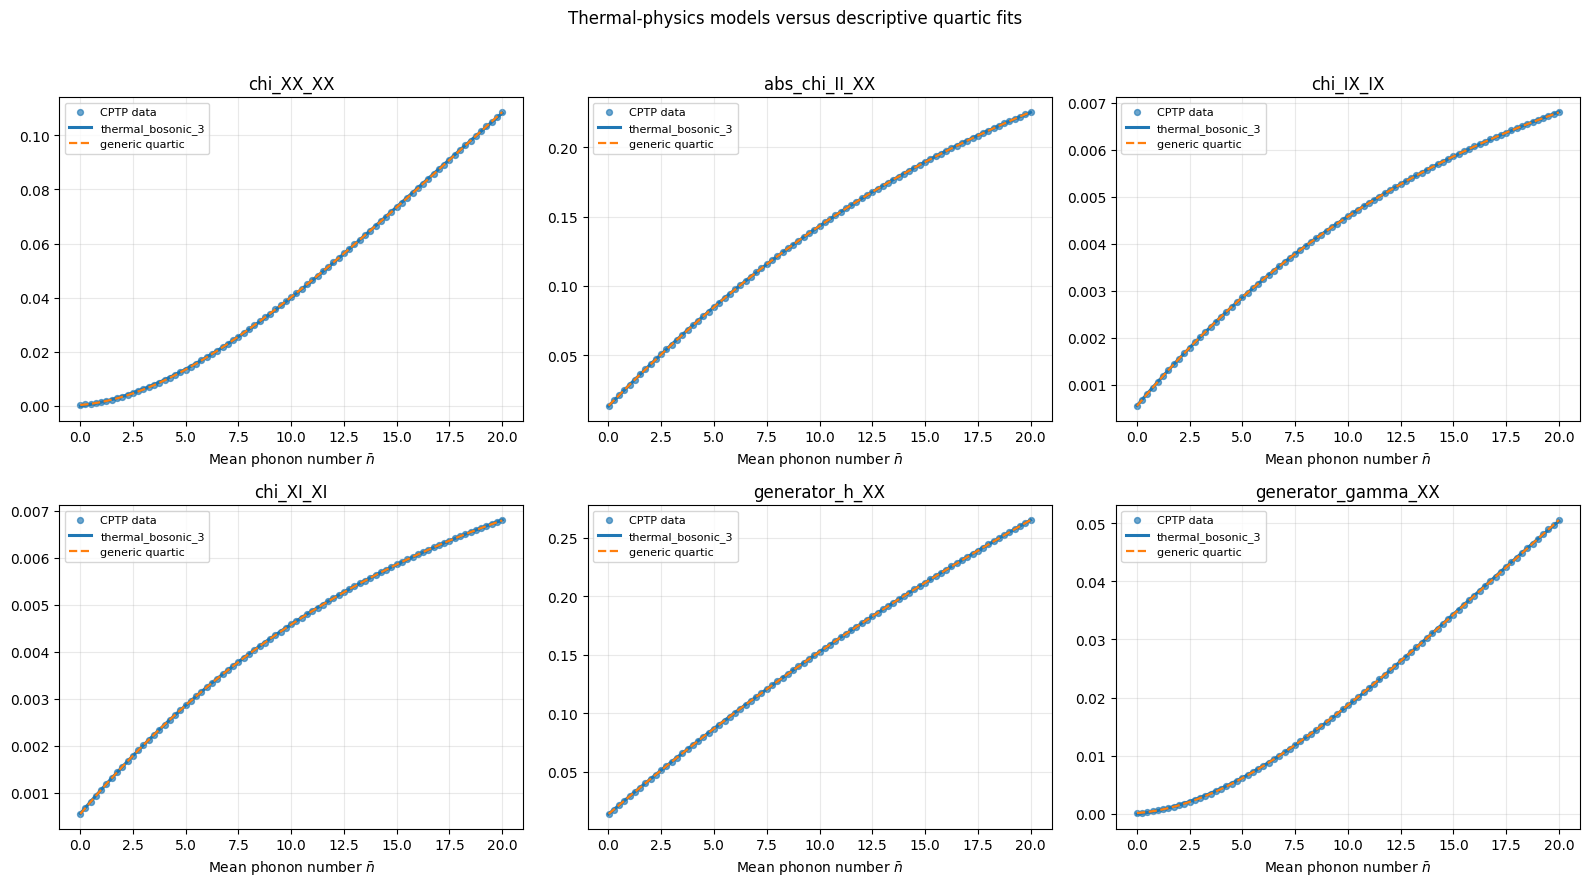

,check,status,result
0,CPTP projection,complete,"CP=81/81, TP=81/81"
1,CPTP conclusion stability,complete,"Top-12 overlap=12/12, max ||delta chi||_F=4.02..."
2,XX error-generator separation,complete,h_XX: 1.3736e-02 -> 2.6508e-01 rad/gate; gamma...
3,Channel-level XX compensation,complete,n_bar=20: avg infidelity 9.8530e-02 -> 4.9633e...
4,hXX-derived drive calibration re-QPT,complete,10/10 temperatures re-QPT; 10 with |h_XX| <= 2.0...
5,Physical-control re-QPT,pending,7/55 non-baseline QPT points
6,Parameter robustness re-QPT,pending,0/45 non-baseline QPT points
7,Thermal physical-model comparison,complete,best physical model saved for 6 targets; gener...


**現時点の結論:** CPTP安定性・generator分解・channel-level補正は完了しました。実Hamiltonianでの制御再QPTとパラメータ頑健性QPTは未完了です。

analysis completed


In [7]:
workflow.validate_config(CONFIG)
RESULTS = workflow.run(CONFIG)
print("analysis completed")

## 6. 独立実行：drive補正後のfull-Hamiltonian再QPT

10温度点を集計します。`RUN_DRIVE_RE_QPT=True`で不足点だけを計算し、完了済み点はキャッシュから自動的に読みます。実行後は論文用チェックリストも即座に更新されます。

In [ ]:
DRIVE_RE_QPT_NBARS = list(CONFIG["HXX_DRIVE_CALIBRATION_NBARS"])
RUN_DRIVE_RE_QPT = False
FORCE_DRIVE_RE_QPT = False

DRIVE_RE_QPT_RESULT = stages.run_drive_feedback_stage(
    CONFIG,
    DRIVE_RE_QPT_NBARS,
    run_qpt=RUN_DRIVE_RE_QPT,
    force_recompute=FORCE_DRIVE_RE_QPT,
    max_feedback_iterations=CONFIG["HXX_MAX_FEEDBACK_ITERATIONS"],
)
print(DRIVE_RE_QPT_RESULT["status"])
if not DRIVE_RE_QPT_RESULT["summary"].empty:
    display(DRIVE_RE_QPT_RESULT["summary"])

## 7. フォノン数ごとのXX角

熱平均の $\bar n$ ではなく、各Fock状態 $|n\rangle$ から出発したときのXX角
$\theta_{XX}^{(n)}=\tfrac12\arg\langle n|U_{S_x=+2}(T)|n\rangle$ を出します。
$h_{XX}^{(n)}=\pi/4-\theta_{XX}^{(n)}$ です。この計算はLindbladノイズを外し、full-order Hamiltonianが生む熱的な角ずれと残留spin-motion entanglementを切り分けます。

既定は代表的な低温・中間・高温の3校正振幅とbaselineの計4曲線です。`FOCK_ANGLE_REFERENCE_NBARS`を変えれば比較点を追加できます。

In [ ]:
import importlib
from IPython.display import Image

stages = importlib.reload(stages)

FOCK_ANGLE_REFERENCE_NBARS = [0.01, 4.0, 20.0]
FOCK_THERMAL_TAIL_TOLERANCE = 1e-5
FOCK_MAX_N = None  # None: 最大bar-nとtail toleranceから自動決定
FOCK_PLOT_MAX_N = 80
FOCK_PHONON_BUFFER = 24
FORCE_FOCK_ANGLE_RECOMPUTE = False
SHOW_FOCK_ANGLE_PROGRESS = True

FOCK_XX_RESULT = stages.run_fock_xx_angle_stage(
    CONFIG,
    FOCK_ANGLE_REFERENCE_NBARS,
    thermal_tail_tolerance=FOCK_THERMAL_TAIL_TOLERANCE,
    max_fock_n=FOCK_MAX_N,
    plot_max_fock_n=FOCK_PLOT_MAX_N,
    phonon_buffer=FOCK_PHONON_BUFFER,
    force_recompute=FORCE_FOCK_ANGLE_RECOMPUTE,
    show_progress=SHOW_FOCK_ANGLE_PROGRESS,
)
print(FOCK_XX_RESULT["status"])
display(FOCK_XX_RESULT["matched_summary"][[
    "condition", "thermal_n_bar", "amplitude",
    "effective_theta_xx_rad", "predicted_h_XX_rad_per_gate",
    "gamma_XX_phase_dispersion_per_gate",
    "gamma_XX_with_residual_motion_per_gate",
    "qpt_h_XX_rad_per_gate", "qpt_gamma_XX_per_gate",
    "thermal_tail_mass",
]])
display(Image(filename=str(FOCK_XX_RESULT["figure_path"])))

## 8. 独立実行：Kirchhoff解析式との直接比較

`K=f_mode[Hz] * t_gate[s]`です。実機のmode周波数を設定するか、既知の`K`を設定してください。両方が`None`の場合は計算せず待機します。

In [ ]:
KIRCHHOFF_MODE_FREQUENCY_HZ = None
KIRCHHOFF_REFERENCE_K = None
KIRCHHOFF_LOOP_NUMBER = 1.0

KIRCHHOFF_DIRECT_RESULT = None
if KIRCHHOFF_MODE_FREQUENCY_HZ is None and KIRCHHOFF_REFERENCE_K is None:
    print("Set KIRCHHOFF_MODE_FREQUENCY_HZ or KIRCHHOFF_REFERENCE_K.")
else:
    KIRCHHOFF_DIRECT_RESULT = stages.run_kirchhoff_direct_comparison_stage(
        CONFIG,
        mode_frequency_hz=KIRCHHOFF_MODE_FREQUENCY_HZ,
        reference_k=KIRCHHOFF_REFERENCE_K,
        loop_number=KIRCHHOFF_LOOP_NUMBER,
    )
    print(KIRCHHOFF_DIRECT_RESULT["reference"])
    display(KIRCHHOFF_DIRECT_RESULT["comparison"])

: 

## 9. 独立実行：他の物理制御との比較

固定drive scan、gate time、detuning、$\sin^2$ pulse、Blackman pulseを同じfull-Hamiltonian QPTとCPTP指標で比較します。既定条件は11候補×6温度=66点

In [ ]:
CONTROL_QPT_NBARS = [0.01, 1.0, 2.0, 4.0, 10.0, 20.0]
RUN_CONTROL_QPT = True
FORCE_CONTROL_QPT = True
SHOW_CONTROL_PROGRESS = True

DRIVE_AMPLITUDE_FACTORS = [0.95, 1.00, 1.05, 1.10, 1.15, 1.20]
GATE_TIME_FACTORS = [0.97, 1.03]
DETUNING_FACTORS = [0.97, 1.03]
PULSE_SHAPES = ["sin2", "blackman"]

PHYSICAL_CONTROL_RESULT = stages.run_physical_control_stage(
    CONFIG,
    CONTROL_QPT_NBARS,
    run_qpt=RUN_CONTROL_QPT,
    force_recompute=FORCE_CONTROL_QPT,
    show_progress=SHOW_CONTROL_PROGRESS,
    amplitude_factors=DRIVE_AMPLITUDE_FACTORS,
    gate_time_factors=GATE_TIME_FACTORS,
    detuning_factors=DETUNING_FACTORS,
    pulse_shapes=PULSE_SHAPES,
)
print(PHYSICAL_CONTROL_RESULT["status"])
display(PHYSICAL_CONTROL_RESULT["candidates"])
display(PHYSICAL_CONTROL_RESULT["best"])

MS gate simulation progress: 6 n_bar values x 1 laser samples x 16 input states = 96 evolutions (16 evolutions / n_bar)
n_bar = 0.01 Simulation Finished (Dim: 20)
n_bar = 1.0 Simulation Finished (Dim: 25)
n_bar = 2.0 Simulation Finished (Dim: 35)
n_bar = 4.0 Simulation Finished (Dim: 67)
n_bar = 10.0 Simulation Finished (Dim: 169)


## 10. 独立実行：パラメータ頑健性

$\eta$、$A/\delta$、gate time、motional dephasing rateを個別に変更し、$h_{XX}$、$\gamma_{XX}$、average infidelityを再評価します。既定条件は9条件×5温度=45点です。条件全体と各条件内のQPT evolutionを2段のprogress barで表示します。

In [ ]:
ROBUSTNESS_QPT_NBARS = [0.01, 1.0, 2.0, 4.0, 6.0, 8.0, 10.0, 12.0, 16.0, 20.0]
RUN_ROBUSTNESS_QPT = True
FORCE_ROBUSTNESS_QPT = True
SHOW_ROBUSTNESS_PROGRESS = True

ETA_FACTORS = [0.8, 1.2]
A_OVER_DELTA_FACTORS = [0.9, 1.1]
ROBUSTNESS_GATE_TIME_FACTORS = [0.95, 1.05]
MOTIONAL_DEPHASING_FACTORS = [0.0, 0.5, 2.0]

ROBUSTNESS_RESULT = stages.run_parameter_robustness_stage(
    CONFIG,
    ROBUSTNESS_QPT_NBARS,
    run_qpt=RUN_ROBUSTNESS_QPT,
    force_recompute=FORCE_ROBUSTNESS_QPT,
    show_progress=SHOW_ROBUSTNESS_PROGRESS,
    eta_factors=ETA_FACTORS,
    a_over_delta_factors=A_OVER_DELTA_FACTORS,
    gate_time_factors=ROBUSTNESS_GATE_TIME_FACTORS,
    motional_dephasing_factors=MOTIONAL_DEPHASING_FACTORS,
)
print(ROBUSTNESS_RESULT["status"])
display(ROBUSTNESS_RESULT["conditions"])
display(ROBUSTNESS_RESULT["summary"])

## 11. 主要結果

詳細なCSV・PNG・PDFは`CONFIG["OUTPUT_DIR"]`以下へ保存されます。

In [ ]:
RESULT_TABLES = [
    "fit_summary_df",
    "advanced_publication_summary_df",
    "final_drive_calibration_df",
]
for table_name in RESULT_TABLES:
    table = RESULTS.get(table_name)
    if isinstance(table, pd.DataFrame) and not table.empty:
        print(table_name)
        display(table)

In [8]:
import os

CPU_COUNT = os.cpu_count() or 4
WORKERS = max(1, min(8, CPU_COUNT - 2))

CONFIG["PARALLEL_WORKERS"] = WORKERS
CONFIG["FAST_PROCESS_WORKERS"] = WORKERS

print(f"Detected logical CPUs: {CPU_COUNT}")
print(f"QPT workers: {WORKERS}")

Detected logical CPUs: 48
QPT workers: 8
